## Notebook 04 — Qualitative interviews: coding, frequencies, charts, thematic analysis

**Data:** `data/interview_coding.csv` (35 respondents: 15 drivers, 15 passengers, 5 experts).  
**Outputs:** frequency tables → `outputs/qualitative/`; figures → `outputs/figures/qual_interview_*.png`.

Thematic columns may contain multiple codes separated by `;`. Each code is counted separately for mention frequencies.

In [1]:
from __future__ import annotations

%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

CSV_PATH = PROJECT_ROOT / "data" / "interview_coding.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "qualitative"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
THEME_COLS = [
    "theme_response_surge",
    "theme_earnings_or_cost",
    "theme_fairness",
    "theme_regulation_or_design",
]

df = pd.read_csv(CSV_PATH)
df["role"] = df["role"].astype(str).str.strip()
print("Loaded:", df.shape)
print(df["role"].value_counts().sort_index())
df.head()

Loaded: (35, 8)
role
Driver       15
Expert        5
Passenger    15
Name: count, dtype: int64


,id,role,experience_or_usage,theme_response_surge,theme_earnings_or_cost,theme_fairness,theme_regulation_or_design,raw_notes
0,D1,Driver,3 years,moves_to_hotspot; stays_online_longer,surge_short; fuel_cost_high,somewhat_fair,reduce_commission; longer_surge,Moves to CBD / Westlands during surge
1,D2,Driver,1.5 years,moves_to_airport,higher_rain_earnings; commission_high,not_fair,surge_forecast,Rain improves earnings
2,D3,Driver,4 years,peak_hour_online,moderate_increase; fuel_high,mixed,reduce_commission,Wants transparency
3,D4,Driver,2 years,moves_to_cbd,slight_increase; maintenance_high,mixed,better_communication,CBD focus
4,D5,Driver,5 years,waits_hotspots,weekend_high; fuel_high,mostly_fair,lower_commission,Surge unpredictable


### Codebook — thematic columns and codes

**How to read the tables:** Each respondent has up to four *thematic* fields. Values inside a field can list several sub-codes separated by `;`. We **split** on `;` and count each sub-code as one **mention** (so mention counts can exceed n=35 and one person can add multiple mentions in the same column).

| Column | What it captures |
|--------|------------------|
| `theme_response_surge` | **Behavior** when surge is high or expected: where drivers move, whether they stay online, or how passengers react (wait, switch app, matatu/boda, still book). |
| `theme_earnings_or_cost` | **Money and operating pressure**: higher fares/earnings vs fuel, commission, traffic, delays, budget strain. |
| `theme_fairness` | **Normative judgement** about surge pricing: fair, unfair, or mixed. |
| `theme_regulation_or_design` | **Desired changes**: transparency, caps, lower fees, alerts, forecasts, regulation, etc. |

**Common sub-code patterns (illustrative):** Spatial supply (`moves_to_cbd`, `moves_westlands`, `waits_hotspots`, `airport_focus`); passenger coping (`wait*`, `uses_matatu`, `uses_other_app`, `books_anyway`); costs (`fuel_high`, `commission_high`, `delay`); policy asks (`transparency`, `limit_surge`, `price_cap`, `reduce_commission`).

Expert-only narrative codes sometimes appear in behavior columns (e.g. `market_imbalance`) — they reflect *how* the expert frames the problem, not a trip behavior.

### 1) Explode themes → long format (one row per code mention)

Semicolon-separated values are split and trimmed so one respondent can contribute multiple counts per column.

In [2]:
def split_themes(cell) -> list[str]:
    if pd.isna(cell) or str(cell).strip() == "":
        return []
    return [p.strip() for p in str(cell).split(";") if p.strip()]


rows = []
for _, r in df.iterrows():
    for col in THEME_COLS:
        for code in split_themes(r[col]):
            rows.append(
                {
                    "id": r["id"],
                    "role": r["role"],
                    "theme_column": col,
                    "code": code,
                }
            )

long_df = pd.DataFrame(rows)
print("Total code mentions:", len(long_df))
long_df.head(12)

Total code mentions: 163


,id,role,theme_column,code
0,D1,Driver,theme_response_surge,moves_to_hotspot
1,D1,Driver,theme_response_surge,stays_online_longer
2,D1,Driver,theme_earnings_or_cost,surge_short
3,D1,Driver,theme_earnings_or_cost,fuel_cost_high
4,D1,Driver,theme_fairness,somewhat_fair
5,D1,Driver,theme_regulation_or_design,reduce_commission
6,D1,Driver,theme_regulation_or_design,longer_surge
7,D2,Driver,theme_response_surge,moves_to_airport
8,D2,Driver,theme_earnings_or_cost,higher_rain_earnings
9,D2,Driver,theme_earnings_or_cost,commission_high


### 2) Frequency counts (overall and by role)

In [3]:
freq_by_col = (
    long_df.groupby(["theme_column", "code"], observed=False)
    .size()
    .reset_index(name="n_mentions")
    .sort_values(["theme_column", "n_mentions"], ascending=[True, False])
)
freq_by_col.to_csv(OUT_DIR / "theme_frequencies_by_column.csv", index=False)
print("Saved:", OUT_DIR / "theme_frequencies_by_column.csv")
print(freq_by_col.groupby("theme_column", group_keys=False).head(10).to_string())

freq_role = (
    long_df.groupby(["theme_column", "code", "role"], observed=False)
    .size()
    .reset_index(name="n_mentions")
    .sort_values(["theme_column", "code", "role"])
)
freq_role.to_csv(OUT_DIR / "theme_frequencies_by_column_and_role.csv", index=False)
print("Saved:", OUT_DIR / "theme_frequencies_by_column_and_role.csv")

fair_primary = (
    df.assign(
        fairness_code=df["theme_fairness"]
        .fillna("")
        .apply(lambda s: split_themes(s)[0] if split_themes(s) else ""),
    )
    .query("fairness_code != ''")
    .groupby(["role", "fairness_code"], observed=False)
    .size()
    .reset_index(name="n")
)
fair_primary.to_csv(OUT_DIR / "fairness_code_by_role.csv", index=False)
print("Saved:", OUT_DIR / "fairness_code_by_role.csv")

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\qualitative\theme_frequencies_by_column.csv
                  theme_column                 code  n_mentions
12      theme_earnings_or_cost            fuel_high           6
26      theme_earnings_or_cost      slight_increase           4
4       theme_earnings_or_cost      commission_high           3
7       theme_earnings_or_cost                delay           3
21      theme_earnings_or_cost     maintenance_high           3
2       theme_earnings_or_cost        budget_impact           2
6       theme_earnings_or_cost            cost_high           2
14      theme_earnings_or_cost            high_cost           2
22      theme_earnings_or_cost             moderate           2
0       theme_earnings_or_cost      better_earnings           1
34              theme_fairness                mixed          15
37              theme_fairness             not_fair          13
33              theme_fairness                 fair

#### Observations — frequency tables

- **Fairness (`theme_fairness`):** The most frequent primary codes are **mixed** (15 mentions) and **not_fair** (13), versus **fair** (4), **somewhat_fair** (1), **mostly_fair** (1), and **not_equitable** (1). The distribution is weighted toward **skepticism or ambiguity**, not uniform acceptance.
- **Earnings / cost (`theme_earnings_or_cost`):** **fuel_high** (6) is the single most cited cost pressure; **slight_increase** (4) and **commission_high** (3) follow, with **delay** and **maintenance_high** (3 each). Many unique low-count codes reflect **diverse** economic framings (experts: volatility, fares in emergencies; passengers: trip cost; drivers: surge brevity and traffic).
- **Regulation / design (`theme_regulation_or_design`):** **transparency** (7) leads; **alerts** (4), **limit_surge** (3), **reduce_commission** (3), and several cap/fee variants appear next. Demands cluster on **information, limits on surge, and platform economics (commission/fees)**.
- **Response to surge (`theme_response_surge`):** Mentions are **fragmented** across many driver repositioning codes (1 mention each for several spatial strategies) and passenger strategies; **waits** (5) is the top aggregate wait-style response, with **books_anyway** (3), **accepts_surge** (2), and **alternative** (2) showing **heterogeneous** coping.

**Interpretation:** Qualitative material stresses **costs and fairness doubts** alongside **operational repositioning** by drivers—useful to **triangulate** with quantitative hotspot / peak-hour patterns, without treating mention counts as a representative survey.

### 3) Charts (saved under `outputs/figures/`)

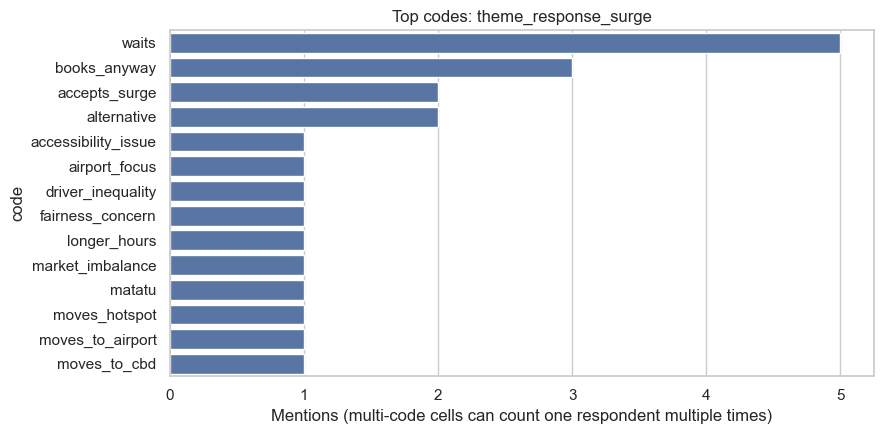

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\qual_interview_top_response_surge.png


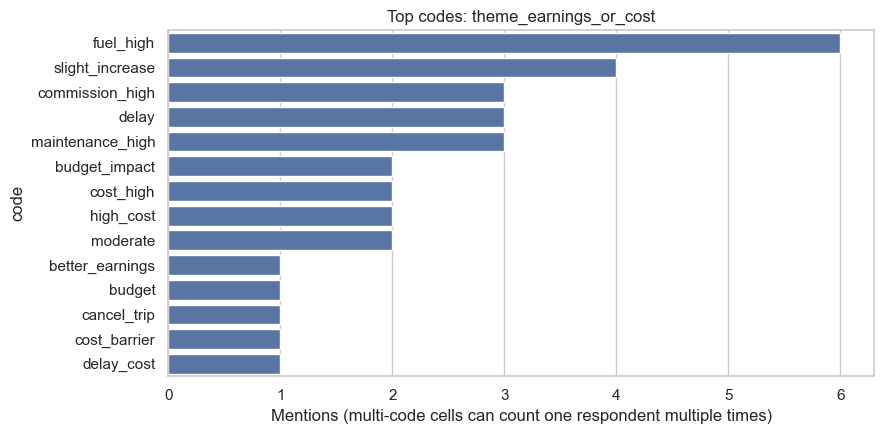

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\qual_interview_top_earnings_or_cost.png


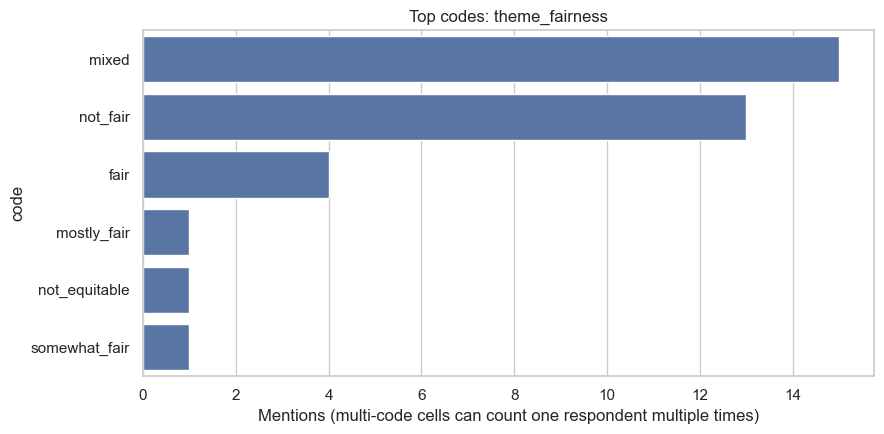

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\qual_interview_top_fairness.png


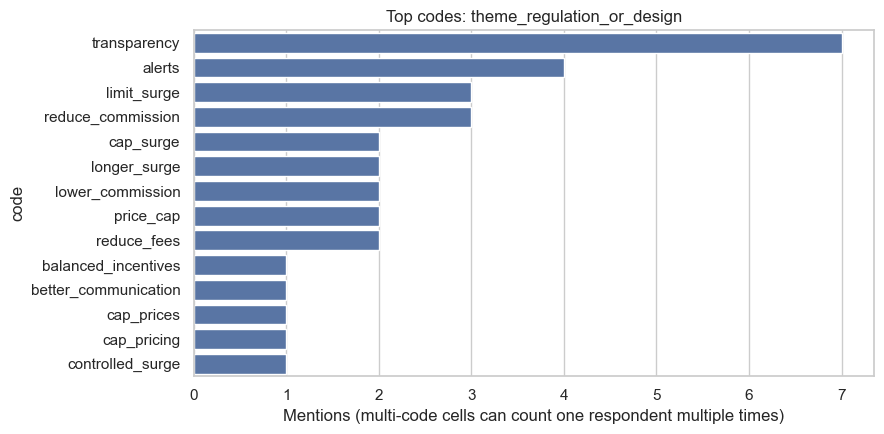

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\qual_interview_top_regulation_or_design.png


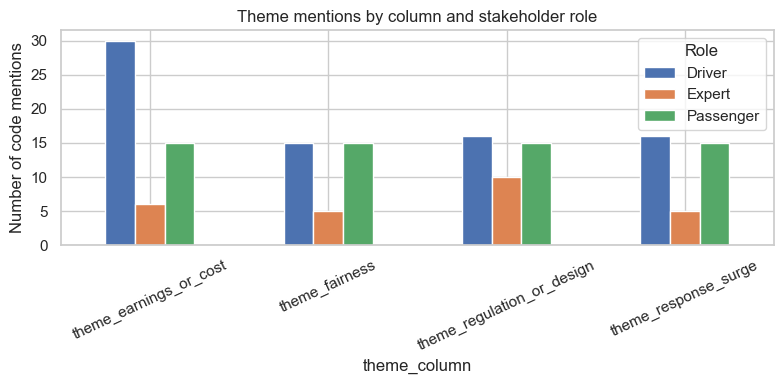

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\qual_interview_mentions_by_role_column.png


In [4]:
def plot_top_codes(theme_col: str, top_n: int = 14):
    sub = freq_by_col[freq_by_col["theme_column"] == theme_col].head(top_n)
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.barplot(data=sub, y="code", x="n_mentions", ax=ax, color="#4c72b0")
    ax.set_title(f"Top codes: {theme_col}")
    ax.set_xlabel("Mentions (multi-code cells can count one respondent multiple times)")
    fig.tight_layout()
    safe = theme_col.replace("theme_", "")
    path = FIG_DIR / f"qual_interview_top_{safe}.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


for col in THEME_COLS:
    plot_top_codes(col, top_n=14)

col_totals = long_df.groupby(["theme_column", "role"], observed=False).size().reset_index(name="n")
fig, ax = plt.subplots(figsize=(8, 4))
pivot_roles = col_totals.pivot(index="theme_column", columns="role", values="n").fillna(0)
pivot_roles.plot(kind="bar", ax=ax, rot=25)
ax.set_title("Theme mentions by column and stakeholder role")
ax.set_ylabel("Number of code mentions")
ax.legend(title="Role")
fig.tight_layout()
path2 = FIG_DIR / "qual_interview_mentions_by_role_column.png"
fig.savefig(path2, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", path2)

#### Observations and interpretations — figures

**`qual_interview_top_response_surge.png`**  
- **Observation:** The horizontal bar chart ranks sub-codes in `theme_response_surge`; you should see **waits** and **books_anyway** toward the top, with many **single-mention** driver strategies (different CBD / Westlands / hotspot / airport labels) spreading mentions thinly.  
- **Interpretation:** **Supply** responses are **geographically varied** (consistent with shifting toward busy areas in your quantitative spatial work); **demand** responses emphasize **waiting, booking anyway, or switching mode/app**—i.e. **substitution and timing**, not a single homogeneous passenger reaction.

**`qual_interview_top_earnings_or_cost.png`**  
- **Observation:** **fuel_high** typically ranks first; **slight_increase**, **commission_high**, **delay**, and **maintenance_high** fill out the upper ranks, with a long tail of context-specific codes.  
- **Interpretation:** Stakeholders frame surge as **not pure upside**: operating costs, **platform take**, and **time/delay** compete with earnings narratives. This supports a thesis discussion of **net benefit** and **distribution** (who gains/loses), beyond average multipliers in the data.

**`qual_interview_top_fairness.png`**  
- **Observation:** **mixed** and **not_fair** dominate the bar chart; positive fairness codes are fewer.  
- **Interpretation:** The sample leans toward **questioning legitimacy** of surge or **reserving judgment**—appropriate for a subsection on **perceived fairness** and policy, without claiming statistical representativeness of all Nairobi users.

**`qual_interview_top_regulation_or_design.png`**  
- **Observation:** **transparency** and **alerts** (and related forecast/communication codes) cluster highly; **limit_surge**, **cap** variants, and **reduce_commission** / **lower_commission** appear prominently.  
- **Interpretation:** There is cross-role convergence on **visibility of pricing** and **constraints on surge or fees**—clear **policy and product-design implications** to pair with your predictive surge findings.

**`qual_interview_mentions_by_role_column.png`**  
- **Observation:** Bar stacks differ by **role** within each theme column (total mentions—not “percent of respondents”). Experts contribute fewer rows overall but may concentrate in fairness/regulation narratives.  
- **Interpretation:** Compare **where** each stakeholder group speaks most (drivers vs passengers vs experts); avoid comparing raw totals as if they were equal sample sizes. Use the chart to **qualify** who drives which theme, then support with **`theme_frequencies_by_column_and_role.csv`** for exact counts.

### 4) Thematic analysis (summary for thesis)

**Design note:** Patterns below synthesize coded columns and `raw_notes`. n=35 (purposive/convenience). Frequencies are **code mentions**, not independent respondents.

**Link to earlier cells:** The **codebook** defines each thematic column; **frequency observations** quote the main counts from `outputs/qualitative/*.csv`; the **figure observations** interpret each `qual_interview_*.png`. Use this subsection as the **integrated narrative** for your thesis (discussion / qualitative chapter).

**Theme A — Driver response to surge:** Spatial reallocation (hotspots, CBD, Westlands, airport, busy areas); some accept all surge rides or extend online time—consistent with high-demand zones in trip data.

**Theme B — Earnings vs costs:** Gains during peak/rain/events offset by fuel, traffic, maintenance, commission; short surge windows limit benefit.

**Theme C — Passenger coping:** Wait for lower price, alternative apps, matatu/boda, or book anyway; outcomes include delay, budget strain, cancellations—supports discussion of elasticity and multimodal substitution.

**Theme D — Fairness:** Mixed ratings overall; passengers more often **not_fair**; experts stress equity, accessibility, market imbalance.

**Theme E — Regulation / product design:** Transparency, price caps/bands, lower commission, alerts, longer surge (drivers), oversight and data transparency (experts)—frame as **policy implications** alongside quantitative surge patterns.

**Limitations:** Non-representative sample; multi-code cells inflate mention counts vs n=35.

In [5]:
# Optional: Excel duplicate of CSV (requires openpyxl)
xlsx_path = OUT_DIR / "interview_coding_for_excel.xlsx"
try:
    df.to_excel(xlsx_path, index=False)
    print("Saved Excel:", xlsx_path)
except Exception as e:
    print("Excel export skipped — use data/interview_coding.csv in Excel, or: pip install openpyxl")
    print(e)

Saved Excel: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\qualitative\interview_coding_for_excel.xlsx


### Artifacts and next steps

The coded data (`data/interview_coding.csv` / `.xlsx`), the frequency CSVs in `outputs/qualitative/`, and the PNG figures in `outputs/figures/qual_interview_*.png` are the artefacts consumed by the thesis discussion chapter. Each theme above is cross-referenced to one or more of these files so the written chapter can quote concrete counts alongside the quantitative surge findings from notebooks 01 and 02.
